In [20]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import src.proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np


# print(config.PROJECT_ROOT)
# print(config.RAW_BASE)
# print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE # this variable now contains the path to the raw data directory, which is defined in the config file. It is used to build the classical conditioning data dictionary using the dio.build_classical_conditioning_dict function. The resulting cc_data variable will contain the structured information about the animals, sessions, and file names for the classical conditioning experiments.
cc_data = dio.build_classical_conditioning_dict(data_root)

pdata_root = config.PROC_BASE # this variable now contains the path to the processed data directory, which is defined in the config file. It is used to build the processed data dictionary using the pdio.build_processed_data_dict function. The resulting pdata variable will contain the structured information about the animals, sessions, and file names for the processed data of the classical conditioning experiments.
print(data_root)
print(pdata_root)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to path: /home/nmldata2/ccaw/Python
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning


In [21]:
animal = "NML_05"
date = "2026_01_04"

state_config = pbs.KinematicStateConfig(
    analysis_hz=100.0,

    move_on_cms=0.50,
    move_off_cms=0.25,

    min_bout_s=0.10,
    join_bout_gaps_s=0.20,

    derivative_window_s=0.15,
    derivative_polyorder=3,

    sustain_fraction=0.60,
    min_sustain_s=0.20,
)

(
    state_timeseries_df,
    state_episodes_df,
) = pbs.build_behavior_state_timeseries(
    animal=animal,
    date=date,
    cc_data=cc_data,
    state_config=state_config,
)

In [22]:
state_timeseries_df.head()

,animal,date,phase,analysis_index,original_sample,session_time_s,cycle_id,led_on,air_on,tone_on,...,speed_net_cms,speed_path_cms,acceleration_net_cmss,jerk_net_cmsss,moving,bout_id,movement_direction,kinematic_state,kinematic_state_code,bout_split_status
0,NML_05,2026_01_04,habituation,0,0,0.00,0,0,0,0,...,-1.161961,1.145987,-40.880819,990.753129,True,1,backward,initiation,1,ok
1,NML_05,2026_01_04,habituation,1,50,0.01,0,0,0,0,...,-1.522267,1.524724,-31.284035,928.603613,True,1,backward,initiation,1,ok
2,NML_05,2026_01_04,habituation,2,100,0.02,0,0,0,0,...,-1.789713,1.801386,-22.308747,866.454097,True,1,backward,initiation,1,ok
3,NML_05,2026_01_04,habituation,3,150,0.03,0,0,0,0,...,-1.970513,1.984141,-13.954953,804.304581,True,1,backward,initiation,1,ok
4,NML_05,2026_01_04,habituation,4,200,0.04,0,0,0,0,...,-2.070884,2.081160,-6.222655,742.155065,True,1,backward,initiation,1,ok


In [23]:
columns_to_view = [
    "animal",
    "date",
    "phase",
    "session_time_s",
    "led_on",
    "air_on",
    "tone_on",
    "environment_mode",
    "distance_net_session_cm",
    "speed_net_cms",
    "speed_path_cms",
    "acceleration_net_cmss",
    "jerk_net_cmsss",
    "bout_id",
    "movement_direction",
    "kinematic_state",
]

display(
    state_timeseries_df[
        columns_to_view
    ].head(30)
)

,animal,date,phase,session_time_s,led_on,air_on,tone_on,environment_mode,distance_net_session_cm,speed_net_cms,speed_path_cms,acceleration_net_cmss,jerk_net_cmsss,bout_id,movement_direction,kinematic_state
0,NML_05,2026_01_04,habituation,0.00,0,0,0,none,0.000000,-1.161961,1.145987,-40.880819,990.753129,1,backward,initiation
1,NML_05,2026_01_04,habituation,0.01,0,0,0,none,-0.025133,-1.522267,1.524724,-31.284035,928.603613,1,backward,initiation
2,NML_05,2026_01_04,habituation,0.02,0,0,0,none,-0.050265,-1.789713,1.801386,-22.308747,866.454097,1,backward,initiation
3,NML_05,2026_01_04,habituation,0.03,0,0,0,none,-0.050265,-1.970513,1.984141,-13.954953,804.304581,1,backward,initiation
4,NML_05,2026_01_04,habituation,0.04,0,0,0,none,-0.075398,-2.070884,2.081160,-6.222655,742.155065,1,backward,initiation
5,NML_05,2026_01_04,habituation,0.05,0,0,0,none,-0.100531,-2.097038,2.100613,0.888148,680.005548,1,backward,initiation
6,NML_05,2026_01_04,habituation,0.06,0,0,0,none,-0.125664,-2.055192,2.050668,7.377456,617.856032,1,backward,initiation
7,NML_05,2026_01_04,habituation,0.07,0,0,0,none,-0.150796,-1.951561,1.939497,13.245269,555.706516,1,backward,initiation
8,NML_05,2026_01_04,habituation,0.08,0,0,0,none,-0.175929,-1.802761,1.748948,19.243144,510.452960,1,backward,initiation
9,NML_05,2026_01_04,habituation,0.09,0,0,0,none,-0.201062,-1.603219,1.479024,23.753530,464.687652,1,backward,initiation


In [24]:
state_sample_counts = (
    state_timeseries_df[
        "kinematic_state"
    ]
    .value_counts()
)

display(state_sample_counts)

kinematic_state
immobile        100780
sustained        16015
deceleration      7147
initiation        3668
Name: count, dtype: int64

In [25]:
analysis_hz = (
    state_timeseries_df
    .attrs["analysis_hz"]
)

state_duration_summary = (
    state_timeseries_df
    .groupby(
        "kinematic_state",
        observed=True,
    )
    .size()
    .rename("number_of_samples")
    .reset_index()
)

state_duration_summary[
    "duration_s"
] = (
    state_duration_summary[
        "number_of_samples"
    ] /
    analysis_hz
)

state_duration_summary[
    "fraction_of_session"
] = (
    state_duration_summary[
        "number_of_samples"
    ] /
    state_duration_summary[
        "number_of_samples"
    ].sum()
)

display(state_duration_summary)

,kinematic_state,number_of_samples,duration_s,fraction_of_session
0,deceleration,7147,71.47,0.056007
1,immobile,100780,1007.80,0.789750
2,initiation,3668,36.68,0.028744
3,sustained,16015,160.15,0.125500


In [26]:
state_episodes_df.head(20)

,animal,date,phase,episode,kinematic_state,onset_analysis_index,offset_analysis_index,onset_original_sample,offset_original_sample,onset_s,...,path_distance_cm,mean_speed_net_cms,mean_speed_path_cms,median_speed_path_cms,peak_speed_path_cms,mean_acceleration_cmss,peak_acceleration_cmss,peak_deceleration_cmss,peak_absolute_jerk_cmsss,rms_jerk_cmsss
0,NML_05,2026_01_04,habituation,1,initiation,0,21,0,1050,0.00,...,0.301593,-0.589179,1.474102,1.524724,2.750159,19.231267,57.443908,-40.880819,990.753129,556.405086
1,NML_05,2026_01_04,habituation,2,sustained,21,168,1050,8400,0.21,...,5.931327,3.788534,3.984568,3.869273,9.521097,-0.350482,67.822264,-61.074443,914.964999,403.068770
2,NML_05,2026_01_04,habituation,3,deceleration,168,198,8400,9900,1.68,...,0.326726,-0.622012,1.109410,1.120413,2.256843,-9.483028,12.959041,-48.157958,378.802560,230.533531
3,NML_05,2026_01_04,habituation,4,immobile,198,223,9900,11150,1.98,...,0.050265,0.165295,0.203551,0.208886,0.470681,3.143812,8.618610,-2.509137,107.126888,71.029967
4,NML_05,2026_01_04,habituation,5,initiation,223,345,11150,17250,2.23,...,1.181239,0.145942,0.949284,0.834239,1.929612,0.955375,17.252578,-25.613441,383.383965,146.602735
5,NML_05,2026_01_04,habituation,6,sustained,345,716,17250,35800,3.45,...,9.977698,1.746177,2.654560,2.201382,8.494020,0.005128,64.989713,-56.383615,934.257261,289.190047
6,NML_05,2026_01_04,habituation,7,deceleration,716,779,35800,38950,7.16,...,0.753982,0.365657,1.190649,1.238614,2.136601,-2.314563,29.339921,-19.771958,394.155140,195.683490
7,NML_05,2026_01_04,habituation,8,immobile,779,800,38950,40000,7.79,...,0.000000,0.075054,0.080207,0.012660,0.406263,1.060722,9.688469,-7.761789,135.143315,85.821855
8,NML_05,2026_01_04,habituation,9,initiation,800,809,40000,40450,8.00,...,0.075398,0.748716,0.748716,0.775781,0.904697,4.831498,9.545511,0.401628,132.397721,96.217860
9,NML_05,2026_01_04,habituation,10,deceleration,809,823,40450,41150,8.09,...,0.100531,0.632679,0.626164,0.663134,0.884595,-4.618671,-0.700919,-8.932354,102.602345,58.996152


In [27]:
episode_columns = [
    "episode",
    "kinematic_state",
    "onset_s",
    "offset_s",
    "duration_s",
    "dominant_environment",
    "net_displacement_cm",
    "path_distance_cm",
    "mean_speed_path_cms",
    "peak_speed_path_cms",
    "peak_acceleration_cmss",
    "peak_deceleration_cmss",
    "peak_absolute_jerk_cmsss",
]

display(
    state_episodes_df[
        episode_columns
    ].head(30)
)

,episode,kinematic_state,onset_s,offset_s,duration_s,dominant_environment,net_displacement_cm,path_distance_cm,mean_speed_path_cms,peak_speed_path_cms,peak_acceleration_cmss,peak_deceleration_cmss,peak_absolute_jerk_cmsss
0,1,initiation,0.00,0.21,0.21,none,-0.150796,0.301593,1.474102,2.750159,57.443908,-40.880819,990.753129
1,2,sustained,0.21,1.68,1.47,none,5.579469,5.931327,3.984568,9.521097,67.822264,-61.074443,914.964999
2,3,deceleration,1.68,1.98,0.30,none,-0.226195,0.326726,1.109410,2.256843,12.959041,-48.157958,378.802560
3,4,immobile,1.98,2.23,0.25,none,0.050265,0.050265,0.203551,0.470681,8.618610,-2.509137,107.126888
4,5,initiation,2.23,3.45,1.22,none,0.175929,1.181239,0.949284,1.929612,17.252578,-25.613441,383.383965
5,6,sustained,3.45,7.16,3.71,none,6.459114,9.977698,2.654560,8.494020,64.989713,-56.383615,934.257261
6,7,deceleration,7.16,7.79,0.63,none,0.201062,0.753982,1.190649,2.136601,29.339921,-19.771958,394.155140
7,8,immobile,7.79,8.00,0.21,none,0.000000,0.000000,0.080207,0.406263,9.688469,-7.761789,135.143315
8,9,initiation,8.00,8.09,0.09,none,0.075398,0.075398,0.748716,0.904697,9.545511,0.401628,132.397721
9,10,deceleration,8.09,8.23,0.14,none,0.100531,0.100531,0.626164,0.884595,-0.700919,-8.932354,102.602345


In [28]:
episode_summary = (
    state_episodes_df
    .groupby(
        "kinematic_state",
        observed=True,
    )
    .agg(
        number_of_episodes=(
            "episode",
            "count",
        ),
        median_duration_s=(
            "duration_s",
            "median",
        ),
        mean_duration_s=(
            "duration_s",
            "mean",
        ),
        median_peak_speed_cms=(
            "peak_speed_path_cms",
            "median",
        ),
        median_peak_acceleration_cmss=(
            "peak_acceleration_cmss",
            "median",
        ),
        median_peak_absolute_jerk_cmsss=(
            "peak_absolute_jerk_cmsss",
            "median",
        ),
    )
    .reset_index()
)

display(episode_summary)

,kinematic_state,number_of_episodes,median_duration_s,mean_duration_s,median_peak_speed_cms,median_peak_acceleration_cmss,median_peak_absolute_jerk_cmsss
0,deceleration,357,0.09,0.200196,0.669218,5.548999,124.753924
1,immobile,357,1.75,2.822969,0.468474,7.581608,171.827044
2,initiation,284,0.06,0.129155,0.774703,1.624360,170.031849
3,sustained,153,0.39,1.046732,1.221510,14.766856,244.812720


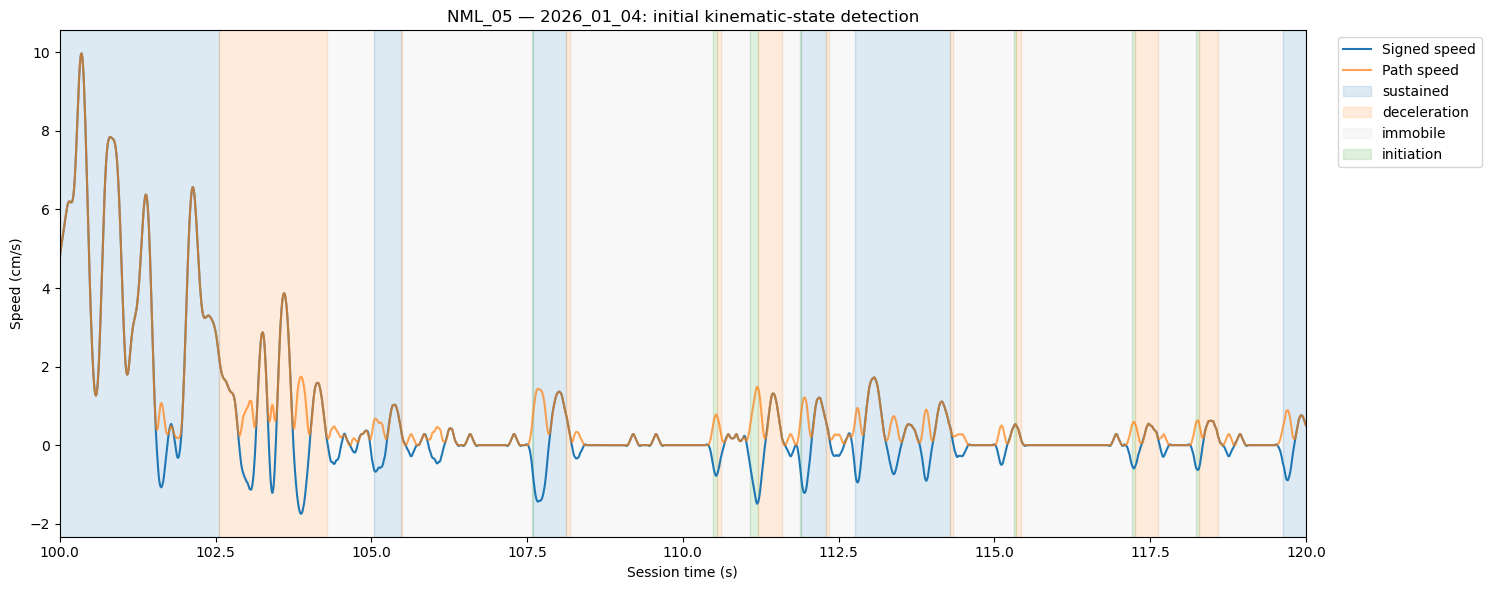

In [29]:
plot_start_s = 100
plot_end_s = 120

plot_df = state_timeseries_df.loc[
    state_timeseries_df[
        "session_time_s"
    ].between(
        plot_start_s,
        plot_end_s,
    )
].copy()

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    plot_df["session_time_s"],
    plot_df["speed_net_cms"],
    label="Signed speed",
)

ax.plot(
    plot_df["session_time_s"],
    plot_df["speed_path_cms"],
    label="Path speed",
    alpha=0.7,
)

state_colors = {
    "immobile": "lightgray",
    "initiation": "tab:green",
    "sustained": "tab:blue",
    "deceleration": "tab:orange",
}

visible_episodes = state_episodes_df.loc[
    (
        state_episodes_df["offset_s"]
        >= plot_start_s
    )
    &
    (
        state_episodes_df["onset_s"]
        <= plot_end_s
    )
]

used_labels = set()

for _, row in visible_episodes.iterrows():

    state = row["kinematic_state"]

    label = (
        state
        if state not in used_labels
        else None
    )

    ax.axvspan(
        row["onset_s"],
        row["offset_s"],
        alpha=0.15,
        color=state_colors[state],
        label=label,
    )

    used_labels.add(state)

ax.set_xlim(
    plot_start_s,
    plot_end_s,
)

ax.set_xlabel("Session time (s)")
ax.set_ylabel("Speed (cm/s)")
ax.set_title(
    f"{animal} — {date}: initial kinematic-state detection"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()